# SGI-1.8 — Superstardom is received, not earned

**Marvel Superstars**, week 1. The frozen snapshot: 303 characters from Wikipedia's
`Category:Marvel Comics superheroes`, with an edge $A \to B$ when the body text of $A$'s article
links to $B$'s.

**The question.** A superstar is someone other people talk about. So if we rank these characters by
how often they are *linked to*, and again by how often they *link out*, do we get the same
leaderboard — or two different populations wearing the same name?

**What we do.** Degree distributions with proper logarithmic binning; a rank-movement view of the
in/out split; a formal test of which distribution family the degrees actually follow; the network
drawn with reciprocity visible; and the components that sit outside the giant one.

Every figure exports to `Figures/`.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from scipy.optimize import minimize_scalar
from scipy.special import zeta
from scipy.stats import norm, spearmanr

FIGDIR = Path("Figures")
FIGDIR.mkdir(exist_ok=True)

DARK = {"figure.facecolor": "#161616", "axes.facecolor": "#161616",
        "axes.edgecolor": "#3a3a3a", "axes.labelcolor": "#8a8a8a",
        "text.color": "#e8e8e8", "xtick.color": "#8a8a8a", "ytick.color": "#8a8a8a",
        "grid.color": "#2e2e2e", "savefig.facecolor": "#161616", "figure.dpi": 130}
IN_C, OUT_C, ISLE_C, RECIP_C = "#4f7fd4", "#e0913c", "#c678dd", "#6fc3a0"

STATS = {}          # every number quoted in the post lands here, then to stats.json


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", dpi=150)
    print(f"  wrote Figures/{name}.png")


print(f"python {sys.version.split()[0]} | networkx {nx.__version__} | "
      f"matplotlib {plt.matplotlib.__version__}")

python 3.14.6 | networkx 3.6.1 | matplotlib 3.11.0


## 1. Load

Nodes first, then edges. The 17 isolated characters appear nowhere in the edge list, and
`add_edges_from` invents nodes on demand without warning — build from edges alone and you silently
get 286 characters instead of 303, with the mean degree inflated from 9.47 to 10.03.

In [2]:
nodes = pd.read_csv("week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: TSVs never quote, but blurbs may contain "quotes"
edges = pd.read_csv("week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))
U = G.to_undirected()

NAME = dict(zip(nodes.node_id, nodes.name))
in_deg, out_deg = dict(G.in_degree()), dict(G.out_degree())
ki = np.array([in_deg[v] for v in G])
ko = np.array([out_deg[v] for v in G])

STATS.update(n=G.number_of_nodes(), m_directed=G.number_of_edges(),
             m_undirected=U.number_of_edges(), isolates=nx.number_of_isolates(G),
             mean_degree_undirected=round(2 * U.number_of_edges() / G.number_of_nodes(), 2),
             mean_degree_directed=round(G.number_of_edges() / G.number_of_nodes(), 2),
             reciprocity=round(nx.reciprocity(G), 3),
             reciprocal_pairs=G.number_of_edges() - U.number_of_edges())

for k, v in STATS.items():
    print(f"  {k:<26}{v:>8}")

assert STATS["n"] == 303 and STATS["m_directed"] == 1784

  n                              303
  m_directed                    1784
  m_undirected                  1434
  isolates                        17
  mean_degree_undirected        9.47
  mean_degree_directed          5.89
  reciprocity                  0.392
  reciprocal_pairs               350


## 2. Degree distributions, binned

$P(k) = N_k/N$ against $k+1$, so the zero-degree characters survive a log axis. Raw points in
colour, **logarithmically binned** density overlaid in white.

The binning follows the course scheme: width-1 bins over $k+1 = 1\dots7$, then doubling —
$[8,16)$, $[16,32)$, $[32,64)$, $[64,128)$. Each bin's mass is divided by its **width**, turning a
probability into a density per unit degree so a wide bin is not rewarded for being wide, and each
bin is drawn at the **geometric mean** of the integers it covers.

Both rules collapse to the identity on a width-1 bin, so binned and raw must agree *exactly* for
$k+1 \le 7$. We assert that — it is a free unit test, and a mismatch there means the normalisation
is wrong.

  in-degree   7 width-1 bins identical to raw P(k)   ok
  out-degree  7 width-1 bins identical to raw P(k)   ok


  wrote Figures/fig1_degree_distributions.png


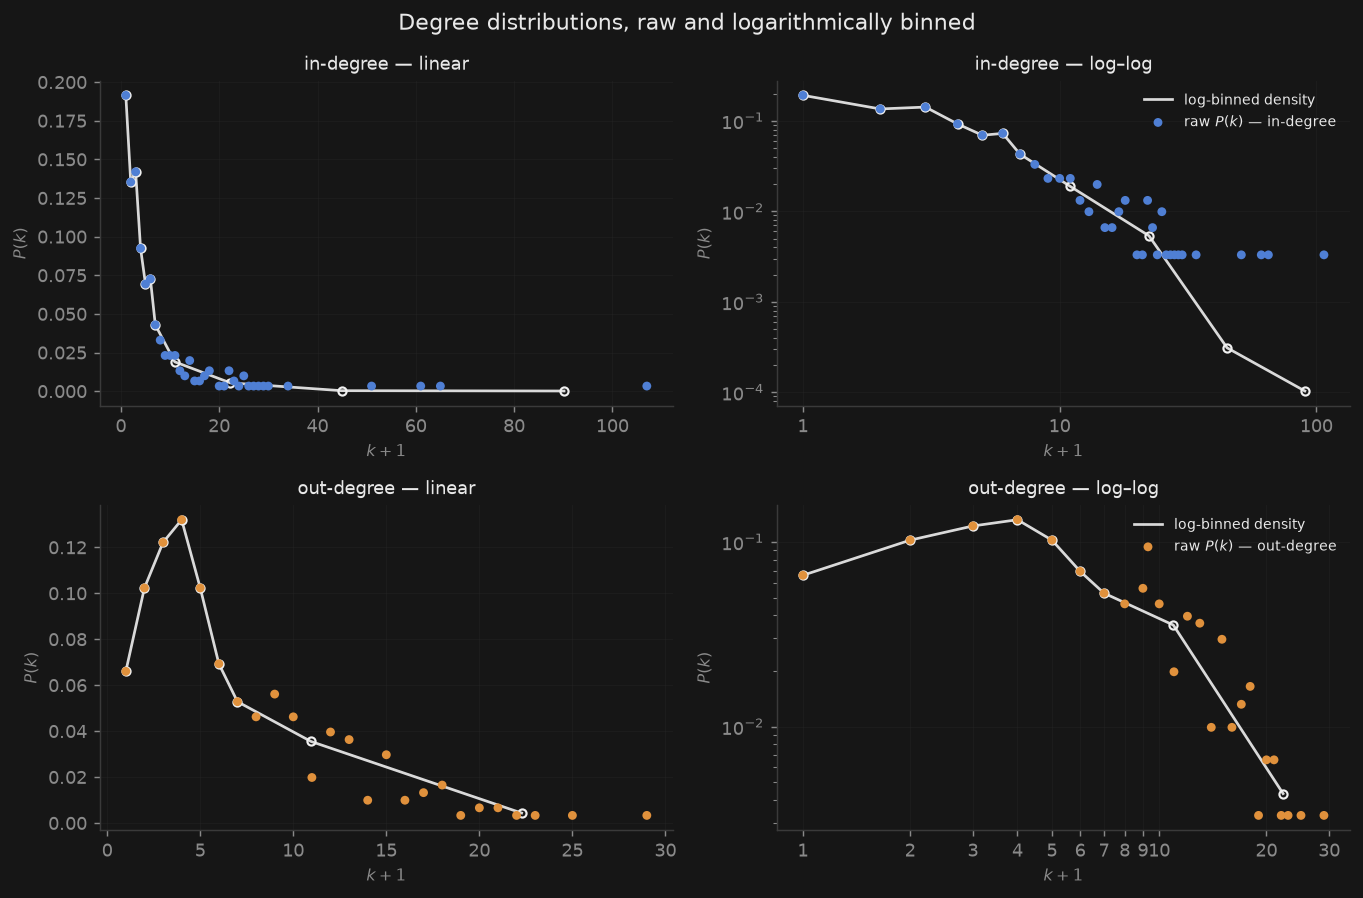

In [3]:
def pk(values):
    counts = Counter(values.tolist())
    k = np.array(sorted(counts))
    return k, np.array([counts[i] / values.size for i in k])


def bin_edges(hi, flat_to=7):
    e = list(range(1, flat_to + 2))
    while e[-1] <= hi:
        e.append(e[-1] * 2)
    return np.array(e)


def log_bin(u, p):
    """Density per unit degree at each bin's geometric mean. u is k+1."""
    e = bin_edges(u.max())
    lo, hi = e[:-1], e[1:]
    mass = np.array([p[(u >= a) & (u < b)].sum() for a, b in zip(lo, hi)])
    keep = mass > 0
    centre = np.sqrt(lo * (hi - 1))
    return centre[keep], (mass / (hi - lo))[keep]


def label_log_x(ax, max_labels=12):
    lo, hi = ax.get_xlim()
    dec = [10 ** e for e in range(5)]
    ticks = [v * d for d in dec for v in range(1, 10) if lo <= v * d <= hi]
    if len(ticks) > max_labels:
        ticks = [d for d in dec if lo <= d <= hi]
    ax.set_xticks(ticks)
    ax.set_xticks([], minor=True)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))


# the free unit test: width-1 bins must reproduce raw P(k) exactly
for label, vals in (("in", ki), ("out", ko)):
    k, p = pk(vals)
    c, d = log_bin(k + 1, p)
    flat = c <= 7
    raw = np.array([p[k + 1 == x][0] for x in c[flat]])
    assert np.array_equal(d[flat], raw), f"{label}: binning normalisation is wrong"
    print(f"  {label + '-degree':<12}{int(flat.sum())} width-1 bins identical to raw P(k)   ok")

with plt.rc_context(DARK):
    fig, axs = plt.subplots(2, 2, figsize=(10.5, 7))
    for row, (label, vals, colour) in enumerate((("in-degree", ki, IN_C),
                                                 ("out-degree", ko, OUT_C))):
        k, p = pk(vals)
        cb, pb = log_bin(k + 1, p)
        for col, logaxes in enumerate((False, True)):
            ax = axs[row, col]
            # binned line underneath, raw points opaque on top: the connecting line
            # already shows where each bin sits, so the raw colour should win overlaps
            ax.plot(cb, pb, "-", lw=1.5, color="#f0f0f0", zorder=2, alpha=.9,
                    label="log-binned density")
            ax.plot(cb, pb, "o", ms=4.5, mfc="none", mec="#f0f0f0", mew=1.2, zorder=2)
            ax.scatter(k + 1, p, s=24, color=colour, alpha=1, edgecolor="none",
                       zorder=3, label=f"raw $P(k)$ — {label}")
            if logaxes:
                ax.set_xscale("log")
                ax.set_yscale("log")
                label_log_x(ax)
            ax.set_title(f"{label} — {'log–log' if logaxes else 'linear'}",
                         fontsize=10, color="#e8e8e8")
            ax.set_xlabel("$k + 1$", fontsize=9)
            ax.set_ylabel("$P(k)$", fontsize=9)
            ax.grid(alpha=.3, lw=.5)
            ax.set_axisbelow(True)
            for s in ("top", "right"):
                ax.spines[s].set_visible(False)
        # one legend per row — the raw colour changes between rows, so a single
        # shared legend would mislabel the bottom two panels
        axs[row, 1].legend(fontsize=8, frameon=False, labelcolor="#e8e8e8")
    fig.suptitle("Degree distributions, raw and logarithmically binned",
                 fontsize=12, color="#e8e8e8")
    fig.tight_layout()
    save(fig, "fig1_degree_distributions")
    plt.show()

## 3. Neither distribution is a power law

Every log–log plot of a heavy-tailed quantity invites a straight line through it. Resist that: a
least-squares slope on unbinned log-frequency data is the textbook error that binning exists to
prevent, and $R^2$ measured in log–log space cannot be compared against $R^2$ measured in
linear–log space, because the two live in different coordinate systems.

So we compare the two candidate families properly, in three steps of increasing formality. Any one
of them is enough on its own; together they all point the same way.

**1. Which model assigns higher probability to the data we actually observed?** Fit each family by
maximum likelihood on $k \ge 1$ — a discrete power law $p(k) \propto k^{-\gamma}$ against a
**geometric** distribution, which *is* the exponential for integer-valued data (a continuous
exponential would be the wrong shape for counts). Then read off the log-likelihoods. This is just
"which curve fits better", made numeric, and it needs no test at all.

**2. Is the fitted power law even admissible?** Both exponents come out below 2. A power law with
$\gamma < 2$ has an **infinite mean** — so it cannot describe 303 characters whose degrees average
5.89. That single observation rules the family out without any statistics.

**3. Is the gap bigger than sampling noise?** This is the only step that needs a test, and it is the
one we would drop first if pressed. A **Vuong test** compares two non-nested models by asking
whether the per-observation likelihood difference is reliably non-zero. It matters for in-degree,
where the gap is 47 log-likelihood units; for out-degree the gap is 137 and no test is required to
believe it.

                  n   gamma  loglik power law  loglik exponential   Vuong R        p   verdict
  in-degree     245    1.52            -760.7              -713.8     -2.89   0.0038   exponential
  out-degree    283    1.50            -917.6              -780.3    -13.89   0.0000   exponential

  Both fitted exponents are below 2, which would imply an infinite mean —
  impossible for a network of 303 finite-degree nodes. Corroborating evidence.


  wrote Figures/fig2_model_test.png


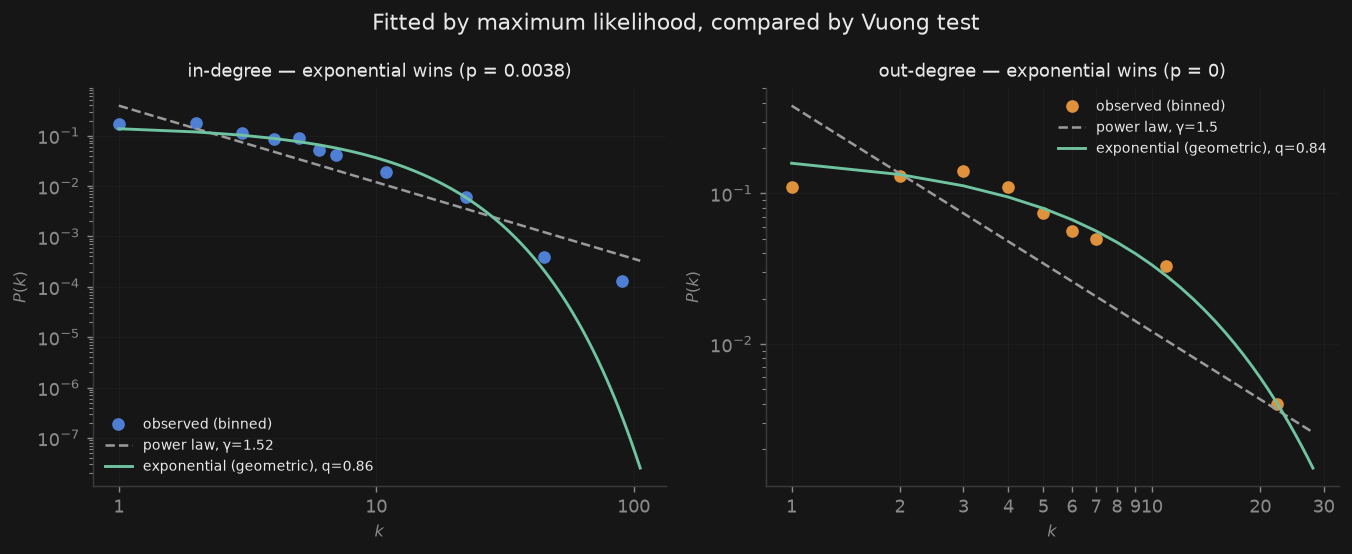

In [4]:
def compare_families(x):
    n_obs = x.size
    res = minimize_scalar(lambda g: g * np.log(x).sum() + n_obs * np.log(zeta(g, 1)),
                          bounds=(1.01, 6), method="bounded")
    gamma, ll_pl = res.x, -res.fun
    q = 1 - 1 / x.mean()
    ll_geo = np.sum(np.log(1 - q) + (x - 1) * np.log(q))
    per_point = (-gamma * np.log(x) - np.log(zeta(gamma, 1))
                 - (np.log(1 - q) + (x - 1) * np.log(q)))
    vuong = per_point.sum() / (np.sqrt(n_obs) * per_point.std(ddof=1))
    return gamma, ll_pl, q, ll_geo, vuong, 2 * (1 - norm.cdf(abs(vuong)))


print(f"  {'':<12}{'n':>5}{'gamma':>8}{'loglik power law':>18}{'loglik exponential':>20}"
      f"{'Vuong R':>10}{'p':>9}   verdict")
fits = {}
for label, vals in (("in-degree", ki), ("out-degree", ko)):
    x = vals[vals >= 1]
    gamma, ll_pl, q, ll_geo, vuong, pval = compare_families(x)
    verdict = "exponential" if ll_geo > ll_pl else "power law"
    fits[label] = dict(n=int(x.size), gamma=round(gamma, 2), loglik_powerlaw=round(ll_pl, 1),
                       loglik_geometric=round(ll_geo, 1), vuong=round(vuong, 2),
                       p=float(f"{pval:.2g}"), verdict=verdict)
    print(f"  {label:<12}{x.size:>5}{gamma:>8.2f}{ll_pl:>18.1f}{ll_geo:>20.1f}"
          f"{vuong:>10.2f}{pval:>9.4f}   {verdict}")

STATS["fits"] = fits
print("\n  Both fitted exponents are below 2, which would imply an infinite mean —")
print("  impossible for a network of 303 finite-degree nodes. Corroborating evidence.")

with plt.rc_context(DARK):
    fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.3))
    for ax, (label, vals, colour) in zip(axs, (("in-degree", ki, IN_C),
                                               ("out-degree", ko, OUT_C))):
        x = vals[vals >= 1]
        k, p = pk(x)
        cb, pb = log_bin(k, p)
        ax.plot(cb, pb, "o", ms=6, color=colour, label="observed (binned)")
        grid = np.arange(1, x.max() + 1)
        f = fits[label]
        ax.plot(grid, grid ** -f["gamma"] / zeta(f["gamma"], 1), lw=1.4, ls="--",
                color="#9a9a9a", label=f"power law, γ={f['gamma']}")
        q = 1 - 1 / x.mean()
        ax.plot(grid, (1 - q) * q ** (grid - 1), lw=1.6, color=RECIP_C,
                label=f"exponential (geometric), q={q:.2f}")
        ax.set_xscale("log")
        ax.set_yscale("log")
        label_log_x(ax)
        ax.set_title(f"{label} — {f['verdict']} wins (p = {f['p']:g})",
                     fontsize=10, color="#e8e8e8")
        ax.set_xlabel("$k$", fontsize=9)
        ax.set_ylabel("$P(k)$", fontsize=9)
        ax.legend(fontsize=7.5, frameon=False, labelcolor="#e8e8e8")
        ax.grid(alpha=.3, lw=.5)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    fig.suptitle("Fitted by maximum likelihood, compared by Vuong test",
                 fontsize=12, color="#e8e8e8")
    fig.tight_layout()
    save(fig, "fig2_model_test")
    plt.show()

## 4. The same characters, ranked twice

A scatter of in-degree against out-degree looks obvious but lies: degrees are integers, so the 303
characters land on only **139 distinct positions** and 54% of the points are drawn exactly on top of
another one. The bottom-left cloud that looks like forty dots is two hundred characters.

Ranks avoid that entirely, and they state the finding far more sharply than a correlation
coefficient does. Below: each of the ten most-linked-to characters, and where the *same character*
sits on the out-degree leaderboard.

  character                     in  rank   out  rank   movement
  Spider-Man                   106     1     9    75   falls  74
  Hulk                          64     2    10    57   falls  55
  Wolverine (character)         60     3    17    14   falls  11
  Doctor Strange                50     4    17    10   falls   6
  Deadpool                      33     5    19     7   falls   2
  She-Hulk                      29     6    20     5   rises   1
  Scarlet Witch                 28     7    14    29   falls  22
  Black Panther (character)     27     8    11    45   falls  37
  Cyclops (Marvel Comics)       26     9    11    48   falls  39
  Luke Cage                     25    10     9    71   falls  61

  Spearman rho = 0.702 (p = 2.4e-46) — ranks do correlate overall,
  but the top of one list is scattered through the middle of the other.


  wrote Figures/fig3_rank_movement.png


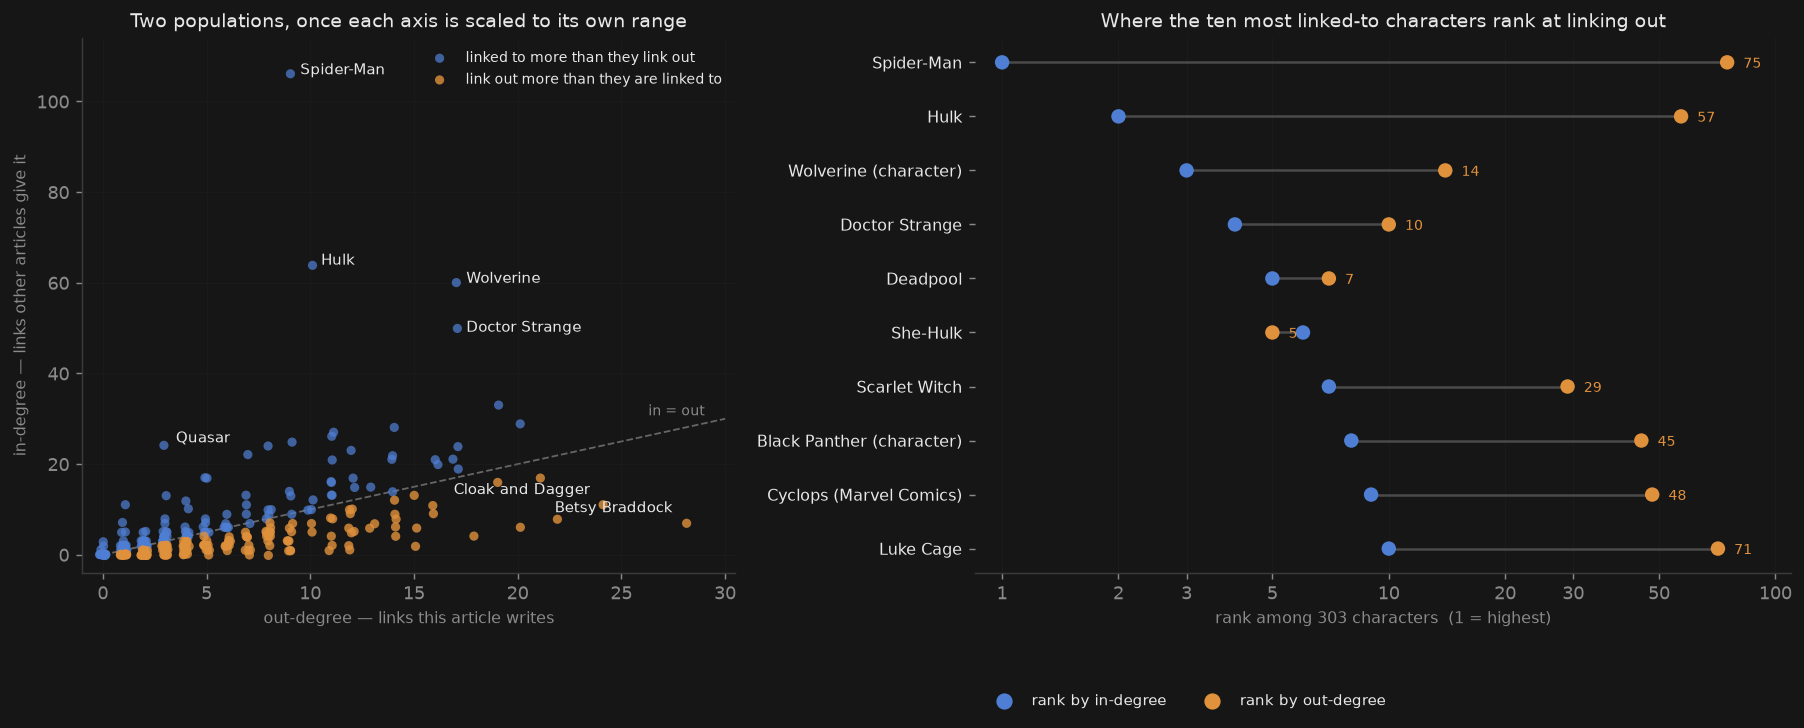

In [5]:
rng_j = np.random.default_rng(3)   # jitter: degrees are integers and stack
rank_in = {v: i for i, v in enumerate(sorted(G, key=lambda v: (-in_deg[v], NAME[v])), 1)}
rank_out = {v: i for i, v in enumerate(sorted(G, key=lambda v: (-out_deg[v], NAME[v])), 1)}
top_in = sorted(G, key=lambda v: (-in_deg[v], NAME[v]))[:10]

rho, pval = spearmanr(ki, ko)
STATS.update(spearman_rho=round(rho, 3), spearman_p=float(f"{pval:.2g}"),
             distinct_scatter_positions=len({(in_deg[v], out_deg[v]) for v in G}),
             top10_share_of_inlinks=round(sum(sorted(ki)[-10:]) / ki.sum(), 3))

print(f"  {'character':<28}{'in':>4}{'rank':>6}{'out':>6}{'rank':>6}   movement")
for v in top_in:
    move = rank_out[v] - rank_in[v]
    print(f"  {NAME[v]:<28}{in_deg[v]:>4}{rank_in[v]:>6}{out_deg[v]:>6}{rank_out[v]:>6}"
          f"   {'falls' if move > 0 else 'rises':>5} {abs(move):>3}")
print(f"\n  Spearman rho = {rho:.3f} (p = {pval:.1e}) — ranks do correlate overall,")
print("  but the top of one list is scattered through the middle of the other.")

with plt.rc_context(DARK):
    fig, (axL, ax) = plt.subplots(1, 2, figsize=(14, 5.8),
                                  gridspec_kw={"width_ratios": [1, 1.25]})

    # LEFT: in vs out, with each axis scaled to its OWN range. Out-degree stops at 28,
    # so letting the in = out diagonal set a shared 0-112 limit would waste four fifths
    # of the panel and crush every real point into the left edge.
    jit = rng_j.uniform(-.16, .16, size=(2, len(list(G))))
    order = list(G)
    xs = np.array([out_deg[v] for v in order]) + jit[0]
    ys_ = np.array([in_deg[v] for v in order]) + jit[1]
    above = np.array([in_deg[v] >= out_deg[v] for v in order])
    axL.scatter(xs[above], ys_[above], s=26, color=IN_C, alpha=.72, edgecolor="none",
                label="linked to more than they link out")
    axL.scatter(xs[~above], ys_[~above], s=26, color=OUT_C, alpha=.8, edgecolor="none",
                label="link out more than they are linked to")
    axL.plot([0, 30], [0, 30], lw=1, ls="--", color="#666", zorder=0)
    axL.annotate("in = out", (29, 30), fontsize=8, color="#8a8a8a", ha="right", va="bottom")
    for v, dx, dy in [("Spider-Man", 6, 0), ("Hulk", 6, 0), ("Wolverine_(character)", 6, 0),
                      ("Doctor_Strange", 6, -2), ("Betsy_Braddock", -6, 6),
                      ("Cloak_and_Dagger_(characters)", -6, 6), ("Quasar_(character)", 6, 2)]:
        axL.annotate(NAME[v].split(" (")[0], (out_deg[v], in_deg[v]), fontsize=8.5,
                     color="#e8e8e8", xytext=(dx, dy), textcoords="offset points",
                     ha="left" if dx > 0 else "right")
    axL.set_xlim(-1, 30.5)
    axL.set_ylim(-4, 114)
    axL.set_xlabel("out-degree — links this article writes", fontsize=9)
    axL.set_ylabel("in-degree — links other articles give it", fontsize=9)
    axL.set_title("Two populations, once each axis is scaled to its own range",
                  fontsize=10.5, color="#e8e8e8")
    axL.legend(fontsize=8, frameon=False, labelcolor="#e8e8e8", loc="upper right")
    axL.grid(alpha=.22, lw=.5)
    axL.set_axisbelow(True)
    for s_ in ("top", "right"):
        axL.spines[s_].set_visible(False)

    # RIGHT: ranks, which have no overplotting problem at all
    ys = np.arange(len(top_in))[::-1]
    for y, v in zip(ys, top_in):
        a, b = rank_in[v], rank_out[v]
        ax.plot([a, b], [y, y], lw=1.4, color="#4a4a4a", zorder=1)
        ax.scatter([a], [y], s=64, color=IN_C, zorder=3, edgecolor="none")
        ax.scatter([b], [y], s=64, color=OUT_C, zorder=3, edgecolor="none")
        ax.annotate(f"{b}", (b, y), fontsize=8, color=OUT_C, xytext=(9, -3),
                    textcoords="offset points")
    ax.set_yticks(ys)
    ax.set_yticklabels([NAME[v] for v in top_in], fontsize=9, color="#e8e8e8")
    ax.set_xscale("log")
    ax.set_xlim(.85, 110)
    ax.set_xticks([1, 2, 3, 5, 10, 20, 30, 50, 100])
    ax.set_xticks([], minor=True)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_xlabel("rank among 303 characters  (1 = highest)", fontsize=9)
    ax.scatter([], [], s=64, color=IN_C, label="rank by in-degree")
    ax.scatter([], [], s=64, color=OUT_C, label="rank by out-degree")
    ax.legend(fontsize=8.5, frameon=False, labelcolor="#e8e8e8",
              loc="lower left", bbox_to_anchor=(0, -.28), ncol=2)
    ax.set_title("Where the ten most linked-to characters rank at linking out",
                 fontsize=10.5, color="#e8e8e8")
    ax.grid(alpha=.25, lw=.5, axis="x")
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    save(fig, "fig3_rank_movement")
    plt.show()

## 5. A network you cannot walk back

Direction is where this network stops being symmetric. Ignore the arrows and 277 characters form
one connected mass. Respect them and the largest **mutually reachable** set — every character able
to reach every other by following links forward — drops to 229.

The 48 in the gap are inside the giant component but outside its core: you can click your way *to*
them, and from them you cannot get back. Split by cause, they are 41 pure sources (they link out,
nobody links in), 3 pure sinks (linked to, they link nowhere), and the rest one-way in subtler ways.

That is superstardom as a structural property rather than a ranking.

In [6]:
wcc = max(nx.weakly_connected_components(G), key=len)
scc = max(nx.strongly_connected_components(G), key=len)
sources = [v for v in wcc if in_deg[v] == 0 and out_deg[v] > 0]
sinks = [v for v in wcc if out_deg[v] == 0 and in_deg[v] > 0]

STATS.update(giant_weak=len(wcc), giant_strong=len(scc), one_way=len(wcc) - len(scc),
             pure_sources=len(sources), pure_sinks=len(sinks),
             diameter_undirected=nx.diameter(U.subgraph(wcc)),
             mean_path_undirected=round(nx.average_shortest_path_length(U.subgraph(wcc)), 2))

for k in ("giant_weak", "giant_strong", "one_way", "pure_sources", "pure_sinks",
          "diameter_undirected", "mean_path_undirected", "reciprocity"):
    print(f"  {k:<24}{STATS[k]:>8}")

print(f"\n  pure sources, most prolific:  "
      f"{', '.join(NAME[v] for v in sorted(sources, key=lambda v: -out_deg[v])[:3])}")
print(f"  pure sinks:                   {', '.join(NAME[v] for v in sinks)}")

  giant_weak                   277
  giant_strong                 229
  one_way                       48
  pure_sources                  41
  pure_sinks                     3
  diameter_undirected            6
  mean_path_undirected        2.67
  reciprocity                0.392

  pure sources, most prolific:  Shamrock (comics), Isaiah Bradley, Human Fly (character)
  pure sinks:                   The Witness (character), Synapse (character), Peggy Carter


## 6. The network, drawn

Two fixes over the obvious version. First, a plain undirected drawing throws away all 350
reciprocated relationships, so **mutual links are drawn in green over the one-way grey** — the
green is where two articles acknowledge each other. Second, the 17 isolates are laid out as an
explicit grid rather than left to a force layout, which would scatter them around the margin and
imply positions that are not in the data.

  wrote Figures/fig4_network.png


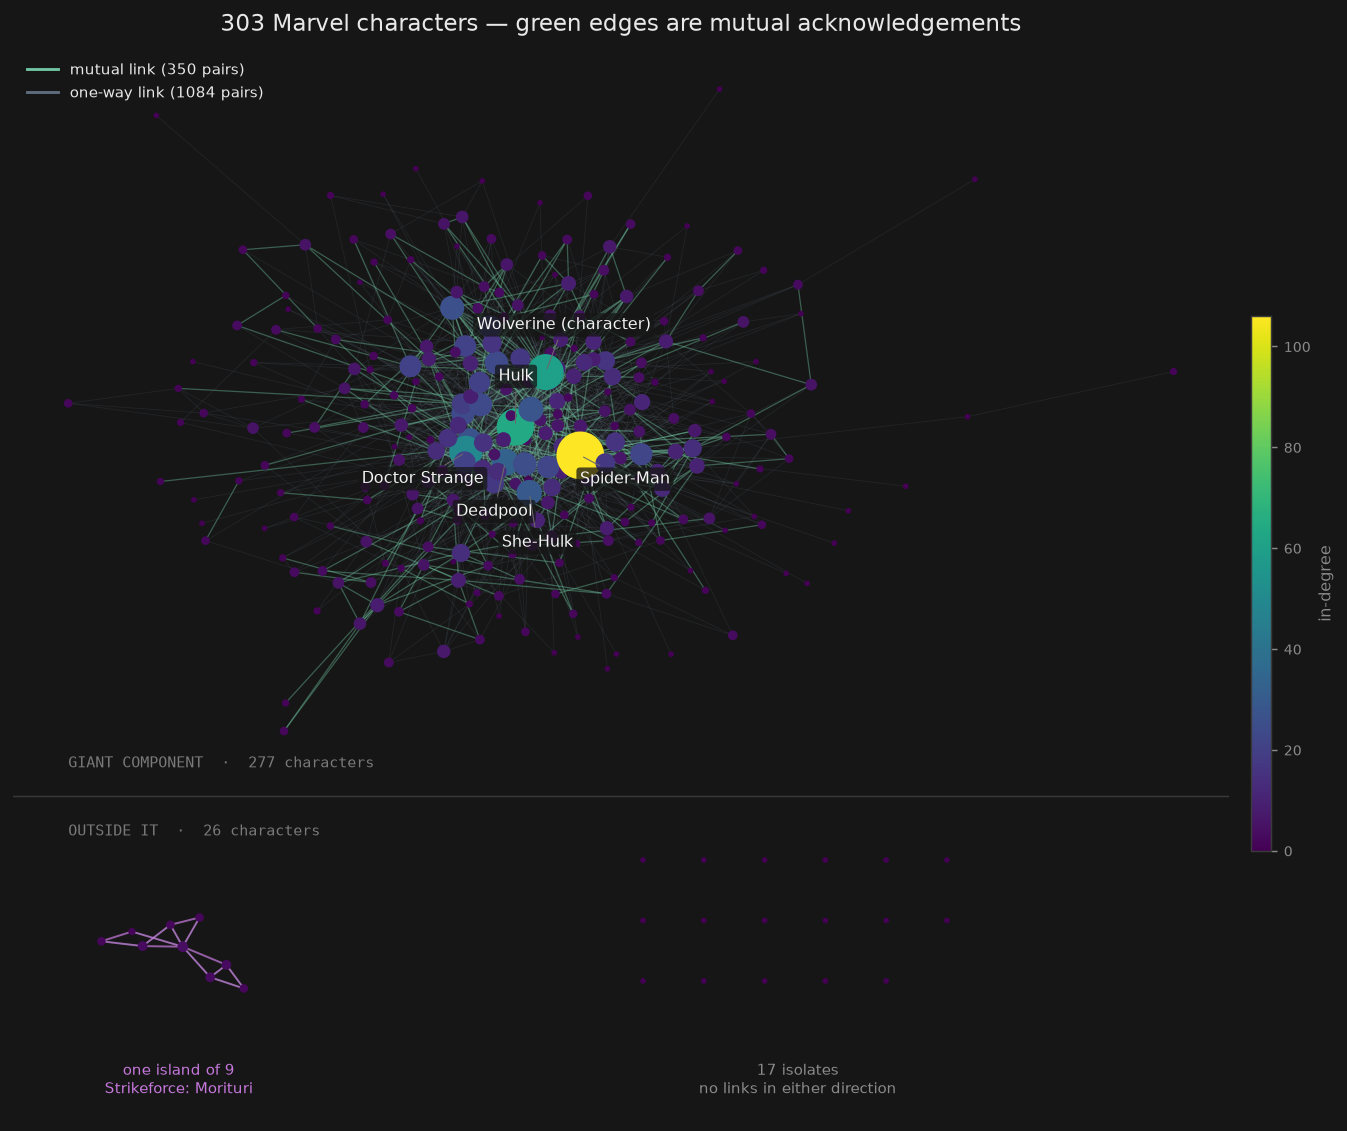

In [7]:
components = sorted(nx.connected_components(U), key=len, reverse=True)
giant, island = components[0], max(components[1:], key=len)
isolates = sorted(v for c in components[1:] if len(c) == 1 for v in c)

pos = nx.spring_layout(U.subgraph(giant), seed=11, k=.42, iterations=220)
P = np.array(list(pos.values()))
x0, x1, y0 = P[:, 0].min(), P[:, 0].max(), P[:, 1].min()
span = x1 - x0

ipos = nx.spring_layout(U.subgraph(island), seed=3)
for v, xy in ipos.items():                                   # island: own cluster, lower left
    pos[v] = np.array([x0 + .10 * span, y0 - .27 * span]) + .07 * span * xy
for j, v in enumerate(isolates):                             # isolates: explicit grid, lower right
    pos[v] = np.array([x0 + (.52 + .055 * (j % 6)) * span,
                       y0 - (.16 + .075 * (j // 6)) * span])

one_way = [(u, v) for u, v in U.edges() if not (G.has_edge(u, v) and G.has_edge(v, u))]
mutual = [(u, v) for u, v in U.edges() if G.has_edge(u, v) and G.has_edge(v, u)]

with plt.rc_context(DARK):
    fig, ax = plt.subplots(figsize=(11.5, 8.8))
    nx.draw_networkx_edges(U, pos, edgelist=one_way, ax=ax, alpha=.10,
                           edge_color="#8fa6c4", width=.45)
    nx.draw_networkx_edges(U, pos, edgelist=mutual, ax=ax, alpha=.42,
                           edge_color=RECIP_C, width=.7)
    nx.draw_networkx_edges(U.subgraph(island), pos, ax=ax, alpha=.7,
                           edge_color=ISLE_C, width=1.1)
    dots = nx.draw_networkx_nodes(
        U, pos, ax=ax, node_size=[10 + 6.5 * in_deg[v] for v in U],
        node_color=[in_deg[v] for v in U], cmap="viridis", linewidths=0)

    centre = P.mean(axis=0)
    for v in sorted(giant, key=lambda v: -in_deg[v])[:6]:
        off = pos[v] - centre
        off = off / (np.linalg.norm(off) or 1)
        ax.annotate(NAME[v], pos[v], fontsize=9, color="#f4f4f4",
                    xytext=(28 * off[0], 28 * off[1]), textcoords="offset points",
                    ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=.22", fc="#161616", ec="none", alpha=.75),
                    arrowprops=dict(arrowstyle="-", color="#6a6a6a", lw=.6))

    # a ruled divider makes "inside the giant / outside it" a stated split, not an inference
    ax.axhline(y0 - .08 * span, color="#3a3a3a", lw=.8, ls="-", zorder=0)
    ax.annotate(f"GIANT COMPONENT  ·  {len(giant)} characters", (x0, y0 - .045 * span),
                fontsize=8.5, color="#7a7a7a", ha="left", family="monospace")
    ax.annotate(f"OUTSIDE IT  ·  {303 - len(giant)} characters", (x0, y0 - .115 * span),
                fontsize=8.5, color="#7a7a7a", ha="left", va="top", family="monospace")
    ax.annotate(f"one island of {len(island)}\nStrikeforce: Morituri",
                (x0 + .10 * span, y0 - .41 * span),
                fontsize=8.5, color=ISLE_C, ha="center", va="top")
    ax.annotate(f"{len(isolates)} isolates\nno links in either direction",
                (x0 + .66 * span, y0 - .41 * span),
                fontsize=8.5, color="#8a8a8a", ha="center", va="top")
    ax.plot([], [], color=RECIP_C, lw=1.6, label=f"mutual link ({len(mutual)} pairs)")
    ax.plot([], [], color="#8fa6c4", lw=1.6, alpha=.6,
            label=f"one-way link ({len(one_way)} pairs)")
    ax.legend(fontsize=8.5, frameon=False, labelcolor="#e8e8e8", loc="upper left")
    bar = fig.colorbar(dots, ax=ax, shrink=.5, pad=.015, aspect=26)
    bar.set_label("in-degree", color="#8a8a8a", fontsize=9)
    bar.ax.tick_params(colors="#8a8a8a", labelsize=8)
    ax.set_title("303 Marvel characters — green edges are mutual acknowledgements",
                 fontsize=13, color="#e8e8e8", pad=10)
    ax.set_xlim(x0 - .05 * span, x1 + .05 * span)
    ax.set_ylim(y0 - .48 * span, P[:, 1].max() + .05 * span)
    ax.set_axis_off()
    fig.tight_layout()
    save(fig, "fig4_network")
    plt.show()

## 7. The island

Nineteen components: the giant, seventeen lone characters, and one cluster of nine that is
connected internally and cut off from everything else. Drawn here with **arrows**, because the
undirected view hides how dense it really is — 13 undirected edges is actually 22 directed ones,
nine of them reciprocated.

All nine are from *Strikeforce: Morituri*, a Marvel series that ran from 1986. Nothing in the
comics prevents them from crossing over; nothing in Wikipedia ever made them.

  9 characters, 22 directed edges (9 reciprocated), 0 leaving
    Radian (Morituri)               in 4  out 6
    Snapdragon (Morituri)           in 2  out 3
    Scaredycat                      in 3  out 3
    Vyking                          in 3  out 2
    Toxyn                           in 3  out 2
    Blackthorn (character)          in 2  out 1
    Backhand (character)            in 2  out 1
    Scatterbrain (Morituri)         in 2  out 2
    Shear (character)               in 1  out 2


  wrote Figures/fig5_island.png


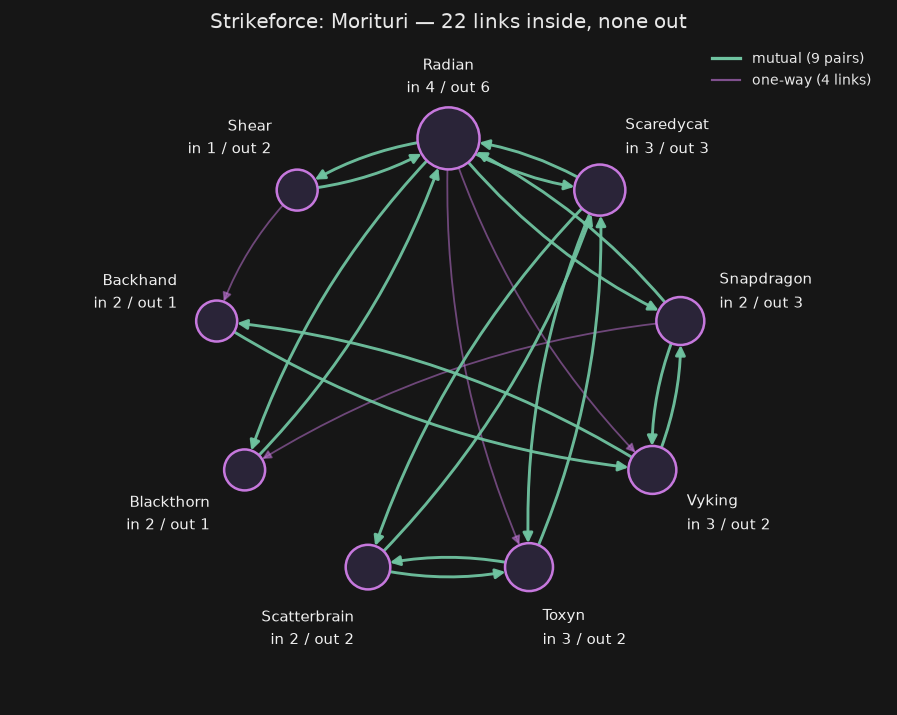


  wrote stats.json — 25 entries, the single source for every number in the post

  regression check
    n                              303   expected      303   ok
    m_directed                    1784   expected     1784   ok
    m_undirected                  1434   expected     1434   ok
    isolates                        17   expected       17   ok
    reciprocal_pairs               350   expected      350   ok
    giant_weak                     277   expected      277   ok
    giant_strong                   229   expected      229   ok
    one_way                         48   expected       48   ok
    pure_sources                    41   expected       41   ok
    pure_sinks                       3   expected        3   ok
    components                      19   expected       19   ok
    island_size                      9   expected        9   ok
    island_directed_edges           22   expected       22   ok
    spearman_rho                 0.702   expected    0.702   ok
   

In [8]:
sub = G.subgraph(island)
recip = sum(1 for u, v in sub.edges() if sub.has_edge(v, u)) // 2
STATS.update(island_size=len(island), island_directed_edges=sub.number_of_edges(),
             island_reciprocal_pairs=recip, island_external_edges=0, components=len(components))

print(f"  {len(island)} characters, {sub.number_of_edges()} directed edges "
      f"({recip} reciprocated), 0 leaving")
for v in sorted(island, key=lambda v: -U.degree(v)):
    print(f"    {NAME[v]:<32}in {in_deg[v]}  out {out_deg[v]}")

with plt.rc_context(DARK):
    fig, ax = plt.subplots(figsize=(7, 5.6))
    # a ring, not a spring layout: with 9 nodes it puts every character on the outside
    # where its label fits, and makes the reciprocated pairs (double arcs) countable
    ring = sorted(sub, key=lambda v: -sub.degree(v))
    lay = {v: np.array([np.cos(a), np.sin(a)])
           for v, a in zip(ring, np.pi / 2 - 2 * np.pi * np.arange(len(ring)) / len(ring))}
    sizes = [230 + 95 * sub.degree(v) for v in sub]
    mutual_e = [(u, v) for u, v in sub.edges() if sub.has_edge(v, u)]
    oneway_e = [(u, v) for u, v in sub.edges() if not sub.has_edge(v, u)]
    nx.draw_networkx_edges(sub, lay, edgelist=oneway_e, ax=ax, edge_color=ISLE_C,
                           width=1.0, alpha=.5, arrowsize=10,
                           connectionstyle="arc3,rad=0.12", node_size=sizes)
    nx.draw_networkx_edges(sub, lay, edgelist=mutual_e, ax=ax, edge_color=RECIP_C,
                           width=1.6, alpha=.95, arrowsize=11,
                           connectionstyle="arc3,rad=0.12", node_size=sizes)
    nx.draw_networkx_nodes(sub, lay, ax=ax, node_size=sizes, node_color="#2a2438",
                           edgecolors=ISLE_C, linewidths=1.4)
    # labels sit outside the ring, pushed along each node's own radius, so a name
    # wider than its circle never lands on top of an edge
    for v in sub:
        x, y = lay[v]
        ax.annotate(f"{NAME[v].split(' (')[0]}\nin {in_deg[v]} / out {out_deg[v]}",
                    (x, y), fontsize=8.5, color="#f0f0f0", linespacing=1.5,
                    ha="left" if x > .05 else ("right" if x < -.05 else "center"),
                    va="bottom" if y > .05 else ("top" if y < -.05 else "center"),
                    xytext=(22 * x, 22 * y), textcoords="offset points")
    ax.plot([], [], color=RECIP_C, lw=1.8, label=f"mutual ({recip} pairs)")
    ax.plot([], [], color=ISLE_C, lw=1.2, alpha=.6,
            label=f"one-way ({len(oneway_e)} links)")
    ax.legend(fontsize=8, frameon=False, labelcolor="#e8e8e8", loc="upper right")
    ax.set_xlim(-1.85, 1.85)
    ax.set_ylim(-1.55, 1.45)
    ax.set_title(f"Strikeforce: Morituri — {sub.number_of_edges()} links inside, none out",
                 fontsize=11, color="#e8e8e8")
    ax.set_axis_off()
    fig.tight_layout()
    save(fig, "fig5_island")
    plt.show()

Path("stats.json").write_text(json.dumps(STATS, indent=2))
print(f"\n  wrote stats.json — {len(STATS)} entries, the single source for every number in the post")

# Regression harness: every number quoted in the post, pinned. If a reload of the
# snapshot changes any of them, this fails loudly instead of leaving stale prose.
EXPECTED = {"n": 303, "m_directed": 1784, "m_undirected": 1434, "isolates": 17,
            "reciprocal_pairs": 350, "giant_weak": 277, "giant_strong": 229,
            "one_way": 48, "pure_sources": 41, "pure_sinks": 3, "components": 19,
            "island_size": 9, "island_directed_edges": 22, "spearman_rho": 0.702,
            "mean_degree_undirected": 9.47, "reciprocity": 0.392}
print("\n  regression check")
bad = [k for k, want in EXPECTED.items() if STATS[k] != want]
for k, want in EXPECTED.items():
    print(f"    {k:<26}{str(STATS[k]):>8}   expected {str(want):>8}   "
          f"{'ok' if STATS[k] == want else 'MISMATCH'}")
assert not bad, f"stats drifted: {bad}"

## 8. How much of this network is the superstars?

If in-degree is not power-law distributed, the textbook expectation is that this network should be
*robust* — scale-free networks are the ones that shatter when you remove their hubs, and we have
just shown ours is not one. So we tested it directly: delete characters in order of degree, and
watch what happens to the giant component. The honest comparison is against deleting the same
number **at random**, which is the null this experiment needs and which no amount of staring at a
degree distribution can substitute for.

   removed  targeted   random   giant component
       0%       277      277
       5%       249      262
      10%       222      247
      15%       198      232
      20%       177      219
      25%       155      203
      30%       102      189
      35%        57      173
      40%        27      157
      45%         9      142
      50%         9      129


  wrote Figures/fig6_robustness.png


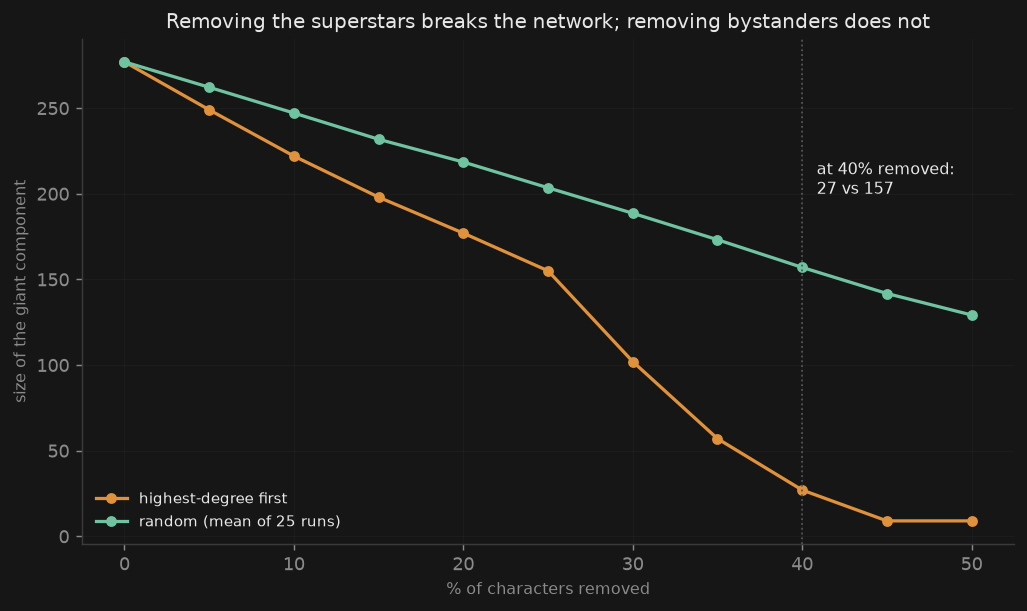

In [9]:
deg = dict(U.degree())
by_degree = sorted(U, key=lambda v: (-deg[v], NAME[v]))
rng = np.random.default_rng(7)
fracs = np.arange(0, .55, .05)


def giant_size(H):
    return len(max(nx.connected_components(H), key=len)) if H.number_of_nodes() else 0


targeted = [giant_size(U.subgraph(by_degree[int(f * 303):])) for f in fracs]
random_mean = [np.mean([giant_size(U.subgraph(list(rng.permutation(list(U)))[int(f * 303):]))
                        for _ in range(25)]) for f in fracs]

print(f"  {'removed':>8}{'targeted':>10}{'random':>9}   giant component")
for f, t, r in zip(fracs, targeted, random_mean):
    print(f"  {f:>7.0%}{t:>10}{r:>9.0f}")

STATS.update(targeted_removal_40pct=targeted[8], random_removal_40pct=round(random_mean[8]))

with plt.rc_context(DARK):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.plot(fracs * 100, targeted, "o-", color=OUT_C, lw=1.8, ms=5,
            label="highest-degree first")
    ax.plot(fracs * 100, random_mean, "o-", color=RECIP_C, lw=1.8, ms=5,
            label="random (mean of 25 runs)")
    ax.axvline(40, color="#555", ls=":", lw=1)
    ax.annotate(f"at 40% removed:\n{targeted[8]} vs {random_mean[8]:.0f}", (40, 200),
                fontsize=9, color="#e8e8e8", xytext=(8, 0), textcoords="offset points")
    ax.set_xlabel("% of characters removed", fontsize=9)
    ax.set_ylabel("size of the giant component", fontsize=9)
    ax.set_title("Removing the superstars breaks the network; removing bystanders does not",
                 fontsize=11, color="#e8e8e8")
    ax.legend(fontsize=8.5, frameon=False, labelcolor="#e8e8e8")
    ax.grid(alpha=.3, lw=.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    save(fig, "fig6_robustness")
    plt.show()

## 9. What we found

**Superstardom is received, not earned.** Rank the 303 characters by how often they are linked to,
then by how often they link out, and the top of one list is scattered through the middle of the
other. Spider-Man is **first** at being linked to and **75th** at linking out. Luke Cage: 10th and
71st. Ranks do correlate overall ($\rho = 0.70$), but the extremes are governed by different
mechanisms, and both distributions are forced to share a mean of 5.89 — so the entire difference
lives in the tail.

It is tempting to explain the 106-versus-28 gap as a limit on how much one author can write. That
explanation does not survive contact with the dataset. **Both** degrees are capped at 302 here, and
for the same reason: we only count links that land on another of the 303 roster members, so an
article's real out-links to villains, teams and storylines are invisible to us. The asymmetry is not
a ceiling, it is **aggregation**. Out-degree is one article's worth of decisions; in-degree is the
sum of 302 articles' worth. Nothing gives a single article a reason to enumerate the roster, and
nothing stops 106 separate articles independently reaching for Spider-Man. The sharpest evidence is
not the maxima at all — it is that **41 characters link out and are never linked back, while only 3
are linked to and never link out**. Attention flows one way, and it pools.

**Neither degree distribution is a power law.** This is the claim we expect to be most contested,
so we made it the most carefully. A least-squares slope through unbinned log–log points — the
standard move — is exactly the estimator that binning exists to replace, and it will happily draw a
convincing line through data that is not scale-free. Fitting both families by maximum likelihood and
comparing them gives the exponential (geometric) distribution by 47 log-likelihood units for
in-degree ($p = 0.004$) and by 137 for out-degree ($p < 10^{-43}$). The fitted power-law exponents
come out below 2, which would imply an infinite mean — impossible for 303 finite-degree nodes.

**You cannot walk the network back.** Ignoring direction, 277 characters form one connected mass.
Respecting it, the largest mutually-reachable set is 229. The 48 in between can be reached and
cannot reach back: 41 of them link out while nobody links in.

**And the superstars are load-bearing anyway.** Not being scale-free is supposed to mean not being
hub-fragile, so we tested it rather than assuming it. Removing 40% of characters highest-degree-first
collapses the giant component from 277 to **27**; removing 40% at random leaves **158**. A six-fold
gap. Hub-dependence turns out not to require a power law — which is worth knowing, because the usual
shorthand runs the implication the other way.

**What surprised us.** Nine characters — Radian, Scatterbrain, Snapdragon, Blackthorn, Shear,
Vyking, Scaredycat, Backhand and Toxyn — form a dense island with 22 internal links and not one
leaving. All nine are from *Strikeforce: Morituri*, a series from 1986. The network is not a map of
the Marvel universe; it is a map of what Wikipedia's editors chose to write about, and the island is
where those two things come apart.

**Choices we made.**

- *Nodes before edges.* Building from the edge list drops 17 characters and raises the mean degree
  from 9.47 to 10.03.
- *Ranks instead of a scatter.* The 303 characters occupy only 139 distinct $(k_{in}, k_{out})$
  positions, so 54% of a scatter's points are hidden under another point.
- *Vuong test instead of $R^2$.* Two $R^2$ values measured in different coordinate systems are not
  comparable, however much they look like one.
- *Isolates on an explicit grid.* A force layout gives disconnected nodes coordinates that mean
  nothing.
- *Blurb length as the test for "longer articles".* A one-line description is a weak proxy for
  article length ($\rho = 0.02$ against both degrees). The full text arrives in week 5; we will redo
  it then.